# Artificial Intelligence and Machine Learning.
 ## Image Classification Using Softmax Regression

# 3.1 Decision Function

Implementing Softmax Function

What this code does

This block converts raw model scores, called logits, into probabilities.
Each row of the output will contain probabilities for all classes, and the sum of each row will be 1. This is the core decision function used in Softmax Regression.

In [1]:
import numpy as np

def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
    z (numpy.ndarray): Logits (raw scores) of shape (m, n), where
                       m = number of samples
                       n = number of classes

    Returns:
    numpy.ndarray: Softmax probability matrix of shape (m, n),
                   where each row sums to 1.
    """

    # Numerical stability:
    # subtract the maximum value in each row to avoid overflow in exp()
    z_shifted = z - np.max(z, axis=1, keepdims=True)

    # Apply exponential to each shifted score
    exp_z = np.exp(z_shifted)

    # Divide by row-wise sum so each row becomes a probability distribution
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

**Softmax Test Function**

What this code does

This checks whether your softmax function is correct by verifying that the probabilities in each row add up to 1, which is the main property of softmax.

In [2]:
# Example test case
z_test = np.array([[2.0, 1.0, 0.1],
                   [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

# Sum of probabilities in each row
row_sums = np.sum(softmax_output, axis=1)

# Test: every row should sum to 1
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")
print(softmax_output)

Softmax function passed the test case!
[[0.65900114 0.24243297 0.09856589]
 [0.33333333 0.33333333 0.33333333]]


**Implementing Prediction Function**

What this code does

This block uses the softmax probabilities to assign a final class label.
It first computes scores using XW + b, then applies softmax, and finally picks the class with the highest probability.

In [3]:
def predict_softmax(X, W, b):
    """
    Predict the class labels for a set of samples using the trained softmax model.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    numpy.ndarray: Predicted class labels of shape (n,)
    """

    # Compute raw class scores (logits)
    z = np.dot(X, W) + b

    # Convert logits to probabilities
    y_pred = softmax(z)

    # Pick the class index with the highest probability for each sample
    predicted_classes = np.argmax(y_pred, axis=1)

    return predicted_classes

**Prediction Test Case**

What this code does

This checks that the prediction function returns one class label for each input sample.

In [4]:
# Define test case
X_test = np.array([[0.2, 0.8],
                   [0.5, 0.5],
                   [0.9, 0.1]])

W_test = np.array([[0.4, 0.2, 0.1],
                   [0.3, 0.7, 0.5]])

b_test = np.array([0.1, 0.2, 0.3])

# Predict class labels
y_pred_test = predict_softmax(X_test, W_test, b_test)

# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


# 3.2 Implementation of Loss and Cost Function

**Implementing Categorical Cross-Entropy Loss Function**

What this code does

This block measures how wrong the model’s predicted probabilities are.
If the model gives high probability to the correct class, the loss is small. If it gives low probability to the correct class, the loss becomes large.

In [5]:
def loss_softmax(y_pred, y):
    """
    Compute the average categorical cross-entropy loss.

    Parameters:
    y_pred (numpy.ndarray): Predicted probabilities of shape (n, c)
    y (numpy.ndarray): True one-hot encoded labels of shape (n, c)

    Returns:
    float: Average cross-entropy loss
    """

    # Small value to prevent log(0), which is undefined
    epsilon = 1e-12

    # Clip probabilities so they stay in a safe range
    y_pred = np.clip(y_pred, epsilon, 1.0 - epsilon)

    # Number of samples
    n = y.shape[0]

    # Cross-entropy loss formula
    loss = -np.sum(y * np.log(y_pred)) / n

    return loss

**Test Case for Loss Function**

What this code does

This checks that the loss is smaller for correct predictions and larger for wrong predictions.

In [6]:
# Define correct predictions (low loss expected)
y_true_correct = np.array([[1, 0, 0],
                           [0, 1, 0],
                           [0, 0, 1]])

y_pred_correct = np.array([[0.9, 0.05, 0.05],
                           [0.1, 0.85, 0.05],
                           [0.05, 0.1, 0.85]])

# Define incorrect predictions (high loss expected)
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                             [0.1, 0.05, 0.85],
                             [0.85, 0.1, 0.05]])

# Compute losses
loss_correct = loss_softmax(y_pred_correct, y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

# Incorrect prediction should have higher loss
assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)

print(f"Cross-Entropy Loss (Correct Predictions): {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions): 0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


**Implementing Cost Function**

What this code does

This block computes the overall model cost on a dataset.
It takes input features X, true labels y, current weights W, and bias b, then:

* computes logits,

* converts them to probabilities,

* computes the average loss.

In [7]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost over all samples.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True one-hot encoded labels of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    float: Average softmax cost
    """

    # Compute raw scores for all samples
    z = np.dot(X, W) + b

    # Convert raw scores to probabilities
    y_pred = softmax(z)

    # Compute average cross-entropy loss
    total_loss = loss_softmax(y_pred, y)

    return total_loss

**Test Case for Cost Function**

What this code does

This checks that the model cost is lower when predictions are better, and higher when predictions are worse.

In [8]:
# Example 1: Better prediction
X_correct = np.array([[1.0, 0.0],
                      [0.0, 1.0]])

y_correct = np.array([[1, 0],
                      [0, 1]])

W_correct = np.array([[5.0, -2.0],
                      [-3.0, 5.0]])

b_correct = np.array([0.1, 0.1])

# Example 2: Worse prediction
X_incorrect = np.array([[0.1, 0.9],
                        [0.8, 0.2]])

y_incorrect = np.array([[1, 0],
                        [0, 1]])

W_incorrect = np.array([[0.1, 2.0],
                        [1.5, 0.3]])

b_incorrect = np.array([0.5, 0.6])

# Compute costs
cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

# Incorrect predictions should have higher cost
assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)

print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133349324
Cost for incorrect prediction: 0.29930861359446115
Test passed!


#3.3 Implementation of Gradient Descent Algorithm

**Computing Gradients against W and b**

What this code does

This block computes how much the weights and biases should change to reduce the loss.
These gradients are the directions used by gradient descent to improve the model.

In [9]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute gradients of the cost function with respect to W and b.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True one-hot encoded labels of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)

    Returns:
    tuple: (grad_W, grad_b)
    """

    # Number of samples
    n = X.shape[0]

    # Compute logits
    z = np.dot(X, W) + b

    # Convert logits to probabilities
    y_pred = softmax(z)

    # Gradient of loss with respect to weights
    grad_W = np.dot(X.T, (y_pred - y)) / n

    # Gradient of loss with respect to biases
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

**Test Case for Compute Gradient Softmax Function**

What this code does

This verifies that your gradient function gives the same result as a manually computed gradient.

In [10]:
# Define a simple feature matrix and true labels
X_test = np.array([[0.2, 0.8],
                   [0.5, 0.5],
                   [0.9, 0.1]])

y_test = np.array([[1, 0, 0],
                   [0, 1, 0],
                   [0, 0, 1]])

# Define weight matrix and bias vector
W_test = np.array([[0.4, 0.2, 0.1],
                   [0.3, 0.7, 0.5]])

b_test = np.array([0.1, 0.2, 0.3])

# Compute gradients using the function
grad_W, grad_b = compute_gradient_softmax(X_test, y_test, W_test, b_test)

# Manual computation
z_test = np.dot(X_test, W_test) + b_test
y_pred_test = softmax(z_test)

grad_W_manual = np.dot(X_test.T, (y_pred_test - y_test)) / X_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test, axis=0) / X_test.shape[0]

# Check if both match
assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W are not equal.\nExpected: {grad_W_manual}\nGot: {grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b are not equal.\nExpected: {grad_b_manual}\nGot: {grad_b}"
)

print("Gradient w.r.t. W:", grad_W)
print("Gradient w.r.t. b:", grad_b)
print("Test passed!")

Gradient w.r.t. W: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


**Gradient Descent Algorithm**

What this code does

This block repeatedly:

* computes the gradients,

* updates weights and bias,

* stores the cost value,
so that the model gradually learns better parameter values.

In [11]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.

    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d)
    y (numpy.ndarray): True one-hot encoded labels of shape (n, c)
    W (numpy.ndarray): Weight matrix of shape (d, c)
    b (numpy.ndarray): Bias vector of shape (c,)
    alpha (float): Learning rate
    n_iter (int): Number of iterations
    show_cost (bool): Whether to print cost during training

    Returns:
    tuple: Optimized weights, biases, and cost history
    """

    # Store cost after each iteration
    cost_history = []

    # Repeat parameter updates for the given number of iterations
    for i in range(n_iter):

        # Step 1: Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Step 2: Update weights and biases in the opposite direction of the gradient
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # Step 3: Compute current cost after update
        cost = cost_softmax(X, y, W, b)

        # Save cost for plotting later
        cost_history.append(cost)

        # Print cost occasionally if requested
        if show_cost and (i % 100 == 0 or i == n_iter - 1):
            print(f"Iteration {i}: Cost = {cost:.6f}")

    return W, b, cost_history

#3.4 Preparing the Dataset

**Load and Prepare MNIST Dataset**

What this code does

This block:

* loads the MNIST CSV file,

* separates labels and pixel features,

* normalizes pixel values to the range 0 to 1,

* splits the data into training and testing sets,

* and displays one sample image for each digit.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets,
    and plots one image per class.

    Arguments:
    csv_file (str): Path to the CSV file containing MNIST data
    test_size (float): Proportion of the data to use as test set
    random_state (int): Random seed for reproducibility

    Returns:
    X_train, X_test, y_train, y_test
    """

    # Load CSV file into a DataFrame
    df = pd.read_csv(csv_file)

    # First column contains digit labels
    y = df.iloc[:, 0].values

    # Remaining columns contain pixel values
    X = df.iloc[:, 1:].values

    # Normalize pixel values from [0, 255] to [0, 1]
    X = X / 255.0

    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Plot one image per class to verify data visually
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

**Plot Sample Images**

What this code does

This block shows one example image for each digit class from 0 to 9.
It helps confirm that the dataset has been loaded correctly and that each image can be reshaped into 28 × 28 form. The worksheet also shows an example output figure for this visualization.

In [13]:
def plot_sample_images(X, y):
    """
    Plot one sample image for each digit class (0-9).

    Arguments:
    X (numpy.ndarray): Feature matrix containing flattened pixel values
    y (numpy.ndarray): Labels corresponding to images
    """

    # Create a figure with enough space for 10 images
    plt.figure(figsize=(10, 4))

    # Get all unique digit classes
    unique_classes = np.unique(y)

    # Loop through each digit class
    for i, digit in enumerate(unique_classes):

        # Find the first example of that digit
        index = np.where(y == digit)[0][0]

        # Reshape the 784-length vector back into 28x28 image
        image = X[index].reshape(28, 28)

        # Create subplot position
        plt.subplot(2, 5, i + 1)

        # Show the image in grayscale
        plt.imshow(image, cmap='gray')

        # Title for each image
        plt.title(f"Digit: {digit}")

        # Remove axis ticks for cleaner display
        plt.axis('off')

    # Adjust layout and display the figure
    plt.tight_layout()
    plt.show()

**Load the Data**

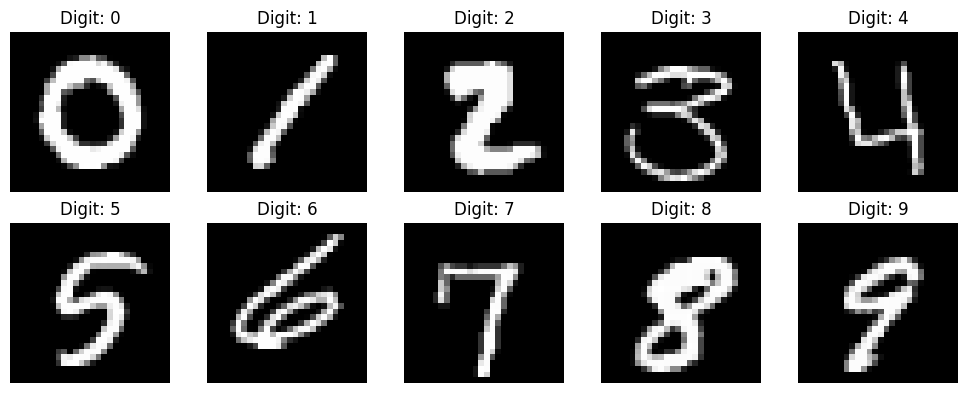

In [16]:
X_train, X_test, y_train, y_test = load_and_prepare_mnist("/content/drive/MyDrive/Artifical Intelligence and Machine Learning/Dataset/mnist_train.csv")

#3.5 Training of the Model

**Shape Check before Training**

What this code does

This checks that the number of feature rows and label rows match before training starts. That prevents shape mismatch errors later in matrix operations.

In [17]:
# Check that each training sample has a corresponding label
assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)

print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Move forward: Dimension of Feature Matrix X and label vector y matched.


**Training of the Softmax Regression Model**

What this code does

This block prepares labels in one-hot encoded form, initializes model parameters, trains the model using gradient descent, and then plots cost vs iterations. The worksheet shows an expected decreasing cost curve for this stage.

Iteration 0: Cost = 2.192134
Iteration 100: Cost = 0.599671
Iteration 200: Cost = 0.481305
Iteration 300: Cost = 0.432127
Iteration 400: Cost = 0.403630
Iteration 500: Cost = 0.384450
Iteration 600: Cost = 0.370385
Iteration 700: Cost = 0.359481
Iteration 800: Cost = 0.350693
Iteration 900: Cost = 0.343403
Iteration 999: Cost = 0.337278


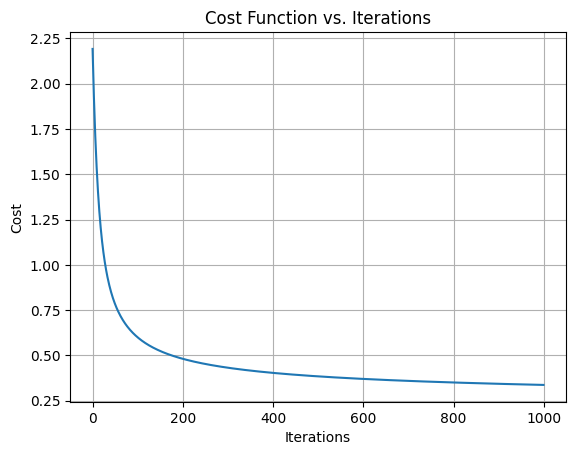

In [18]:
from sklearn.preprocessing import OneHotEncoder

# Check if labels are still in 1D form
if len(y_train.shape) == 1:
    try:
        encoder = OneHotEncoder(sparse_output=False)
    except TypeError:
        # For older sklearn versions
        encoder = OneHotEncoder(sparse=False)

    # Convert training labels to one-hot encoding
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))

    # Use the same encoder for test labels
    y_test = encoder.transform(y_test.reshape(-1, 1))

# Number of features (784 for MNIST if using raw pixels)
d = X_train.shape[1]

# Number of classes (10 digits: 0 to 9)
c = y_train.shape[1]

# Initialize weights with small random numbers
W = np.random.randn(d, c) * 0.01

# Initialize bias with zeros
b = np.zeros(c)

# Hyperparameters
alpha = 0.1      # Learning rate
n_iter = 1000    # Number of training iterations

# Train model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)

# Plot cost over time to check if training is improving
plt.plot(cost_history)
plt.title("Cost Function vs. Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

#3.6 Evaluating Your Model Performance

**Evaluation Function**

What this code does

This block computes standard classification metrics:

* confusion matrix,

* precision,

* recall,

* F1-score.

  These help measure how well the model performs on the test set. The worksheet later shows an expected confusion matrix visualization.

In [19]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: confusion matrix, precision, recall, f1 score
    """

    # Build confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute weighted precision, recall, and F1
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

**Putting it all together: How well your model did**

What this code does

This block:

1. predicts labels for the test set,

2. converts one-hot test labels back to class numbers,

3. evaluates the predictions,

4. prints metrics,

5. and visualizes the confusion matrix.


Confusion Matrix:
[[779   0   1   1   3  12   8   0  11   1]
 [  0 889   2   1   1   2   2   2   9   1]
 [  6  10 736  13  26   2  11  16  25   1]
 [  2   5  26 800   1  40   6  12  27  18]
 [  1   1   7   2 774   4  11   2   2  35]
 [ 10   7   5  25  14 586  22   4  21   8]
 [  7   1   7   3   6   9 741   1   9   1]
 [  1  13  16   3  14   4   0 801   2  39]
 [  2  11   9  26   7  25   8   7 728  12]
 [  6   3   6  16  23   7   0  30   6 741]]
Precision: 0.90
Recall: 0.90
F1-Score: 0.90


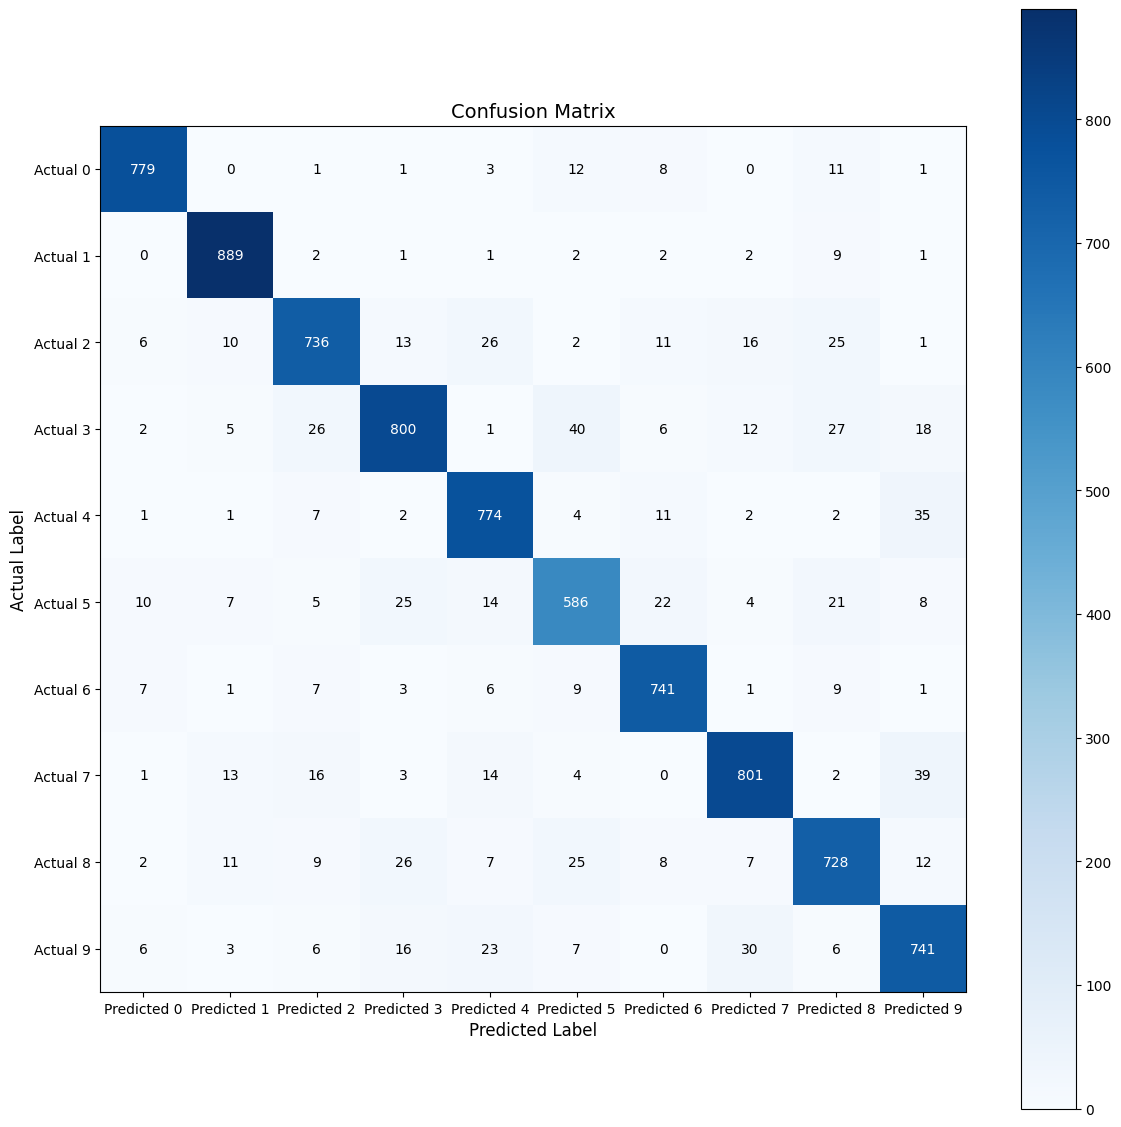

In [20]:
# Predict labels for the test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# Convert one-hot encoded true labels back to class indices
y_test_labels = np.argmax(y_test, axis=1)

# Evaluate predictions
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print metrics
print("\nConfusion Matrix:")
print(cm)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))

# Display confusion matrix as image
cax = ax.imshow(cm, cmap='Blues')

# Number of classes
num_classes = cm.shape[0]

# Set tick marks and labels
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

# Add cell values inside the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black'
        )

# Add titles and labels
ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

# Adjust layout and show color bar
plt.tight_layout()
plt.colorbar(cax)
plt.show()

#4 Exercise - Linear Separability and Logistic Regression

**Re-implement the following code exactly as provided**

What this code does

This section is a separate exercise from the MNIST softmax part.
It compares logistic regression on:

* a linearly separable dataset, where the model should perform well,

* and a non-linearly separable dataset, where a straight-line decision boundary struggles.
The worksheet asks you to reproduce the plots and then interpret the output.

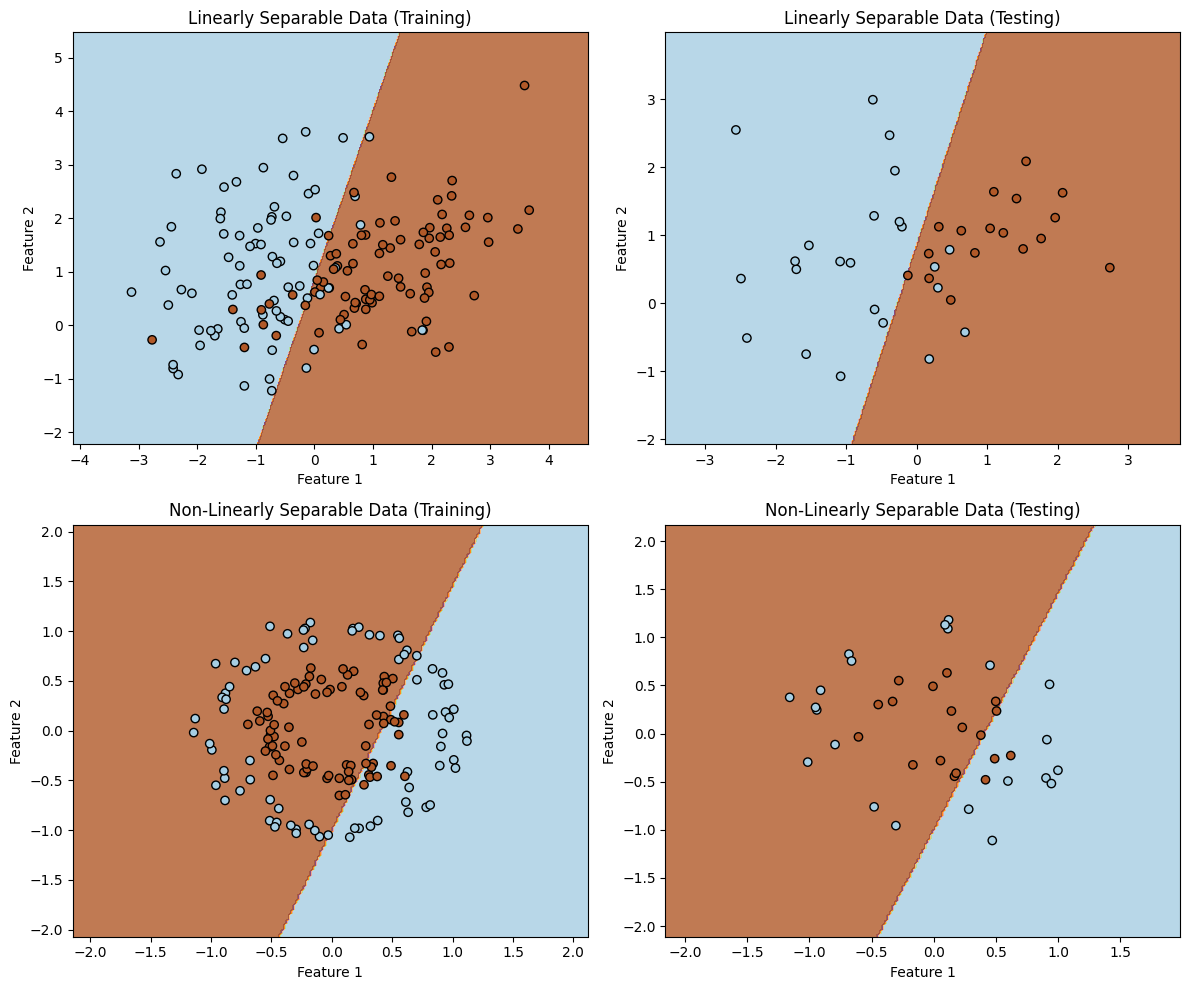

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200,
    noise=0.1,
    factor=0.5,
    random_state=42
)

# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# Function to plot decision boundary
def plot_decision_boundary(ax, model, X, y, title):
    """
    Plot the decision boundary learned by the classifier.
    """

    # Step size used to create the background grid
    h = 0.02

    # Set limits for the plot area
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Create a meshgrid of points
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Predict class for every point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot background decision regions
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)

    # Plot actual data points
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)

    # Add titles and labels
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(
    axes[0, 0],
    logistic_model_linear_separable,
    X_train_linear,
    y_train_linear,
    'Linearly Separable Data (Training)'
)

# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(
    axes[0, 1],
    logistic_model_linear_separable,
    X_test_linear,
    y_test_linear,
    'Linearly Separable Data (Testing)'
)

# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(
    axes[1, 0],
    logistic_model_non_linear_separable,
    X_train_non_linear,
    y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(
    axes[1, 1],
    logistic_model_non_linear_separable,
    X_test_non_linear,
    y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()

# Save the figure as PNG
plt.savefig('decision_boundaries.png')

# Display the plots
plt.show()